Original opensees documentation link: https://opensees.berkeley.edu/wiki/index.php/Moment_Curvature_Example

moment-curvature analysis of a rectangular reinforced concrete section. In this example a Zero Length element with the fiber discretization of the cross section is used. 
<img src="https://opensees.berkeley.edu/wiki/images/5/5f/MomentCurvature.png"></img>


**Video regarding moment-curvature curve**: https://www.youtube.com/watch?v=FMXGwRN50dw

In [1]:
import openseespy.opensees as ops
import opsvis as ovs
import numpy as np
import matplotlib.pyplot as plt


## Section Definition

<img src="https://opensees.berkeley.edu/wiki/images/6/63/MomentCurvatureSection.png" align="left"></img>
<img src="https://opensees.berkeley.edu/wiki/images/0/08/MomentCurvatureSectionDiscritization.png" align="right"></img>


## section variables

In [2]:
#section parameters
d = 24 #inch
w = 15
cov = 1.5 #cover of unconfined concrete in inches
As  =  0.60    # area of no. 7 bars


concrete_coors_ext = [-d/2, w/2, -d/2, -w/2, d/2, -w/2,  d/2, w/2]

rebars_z = np.array([w/2-cov, 0., -w/2+cov])
rebars_y = np.array([d/2-cov, 0., -d/2+cov])

rebars_coors = []
for i,z in enumerate(rebars_z):
    for j,y in enumerate(rebars_y):
        if (z,y)!=(0,0):
            rebars_coors.append((z,y))


## Material properties

In [3]:
#material properties
#concrete
    #core concrete confined
core_conc = 1 #tag
fc_c = -6.0
ec0_c = -0.004
fcu_c = -5.0
ecu_c = -0.014

    #cover concrete unconfined
cover_conc = 2 #tag
fc_u = -5.0
ec0_u = -0.002
fcu_u = -0.0
ecu_u = -0.006

# STEEL
# Reinforcing steel 
steel = 3 #tag
fy =  60.0   # Yield stress
E =  30000.0  # Young's modulus
b = 0.01

In [4]:
def getSection(plotFiberSection = True):
    ops.wipe()
    ops.model("BasicBuilder", '-ndm', 2, '-ndf', 3)
                                        #tag   f'c        ec0   f'cu   ecu
    ops.uniaxialMaterial('Concrete01', core_conc, fc_c, ec0_c, fcu_c, ecu_c)
    ops.uniaxialMaterial('Concrete01', cover_conc, fc_u, ec0_u, fcu_u, ecu_u)
    ops.uniaxialMaterial('Steel01', steel, fy, E, b)

    ops.section('Fiber', 1)
    # Create the concrete core fibers
    #patch('rect', matTag, numSubdivY, numSubdivZ, *crdsI, *crdsJ)
    numSubdivY = 10
    numSubdivZ = 1
    ops.patch('rect', core_conc, numSubdivY, numSubdivZ, *[d/2-cov, w/2-cov, -d/2+cov, -w/2+cov]) #core

    #cover concrete
    #+y, +y, +z, -z
    ops.patch('rect', cover_conc, 2, 1,*[d/2, w/2-cov, d/2-cov, -w/2+cov]) #top cover
    ops.patch('rect', cover_conc, 2, 1, *[-d/2+cov, w/2-cov, -d/2, -w/2+cov]) #bot cover
    ops.patch('rect', cover_conc, 10, 1, *[d/2 , -w/2+cov, -d/2, -w/2]) #right cover
    ops.patch('rect', cover_conc, 10, 1, *[d/2, w/2, -d/2, w/2-cov]) #left cover

    #layer('straight', matTag, numFiber, areaFiber, *start, *end)
    #top bottom mid
    ops.layer('straight', steel, 3, As, *[d/2-cov, w/2-cov], *[ d/2-cov, -w/2+cov])
    ops.layer('straight', steel, 3, As, *[-d/2+cov, w/2-cov,], *[-d/2+cov, -w/2+cov])
    ops.layer('straight', steel, 2, As, *[0, w/2-cov], *[0, -w/2+cov])    

    if plotFiberSection:
        fib_sec_list = [['section', 'Fiber', 1],
                        ['patch', 'rect', core_conc, numSubdivY, numSubdivZ, *[d/2-cov, w/2-cov, -d/2+cov, -w/2+cov]], #core
                        ['patch', 'rect', cover_conc, 2, 1, *[d/2, w/2-cov, d/2-cov, -w/2+cov]], #top
                        ['patch', 'rect', cover_conc, 2, 1, *[-d/2+cov, w/2-cov, -d/2, -w/2+cov]], #bot
                        ['patch', 'rect', cover_conc, 10, 1, *[d/2 , -w/2+cov, -d/2, -w/2]], #right cover
                        ['patch', 'rect', cover_conc, 10, 1, *[d/2, w/2, -d/2, w/2-cov]], #left cover
                            ['layer', 'straight', steel, 3, As, *[d/2-cov, w/2-cov], *[ d/2-cov, -w/2+cov]],
                            ['layer', 'straight', steel, 3, As, *[-d/2+cov, w/2-cov,], *[-d/2+cov, -w/2+cov]],
                            ['layer', 'straight', steel, 2, As, *[0, w/2-cov], *[0, -w/2+cov]],
                       ]
        matcolor = ['lightgrey', 'lightgrey', 'gold', 'w', 'w', 'w']
        ovs.plot_fiber_section(fib_sec_list, matcolor=matcolor)
        plt.axis('equal')

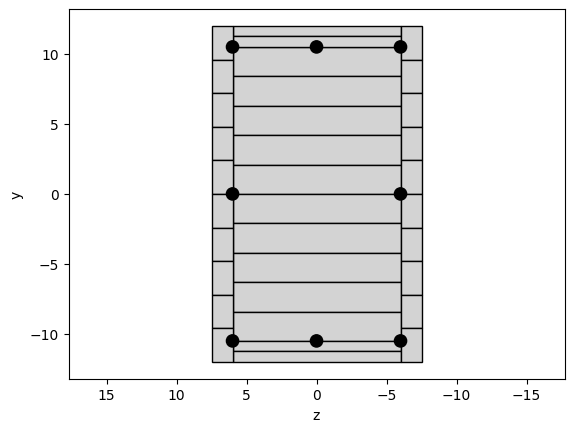

In [5]:
getSection(plotFiberSection = True)

In [25]:
def MomentCurvature(secTag, axialLoad, maxK, numIncr = 1000):
    #we will use zero length element to model the section for moment curvature analysis
    #so define two nodes at 0, 0
    ops.node(1, 0, 0)
    ops.node(2, 0, 0)
    
    # Fix all degrees of freedom except axial and bending
    ops.fix(1, 1, 1, 1)
    ops.fix(2, 0, 1, 0)
    
    #define element
    #element('zeroLength', eleTag, *eleNodes, '-mat', *matTags, '-dir', *dirs, <'-doRayleigh', rFlag=0>, <'-orient', *vecx, *vecyp>)
    ops.element('zeroLengthSection', 1, *[1,2], secTag) 

    #for curvature analysis
    conTS = 1
    linTS = 2
    
    ops.timeSeries('Constant', conTS)
    ops.pattern('Plain', 1, conTS)
    ops.load(2, *[axialLoad, 0, 0])
    
    #define recorders:
	# Define analysis parameters
    ops.integrator('LoadControl', 0.0)
    ops.system('SparseGeneral', '-piv')	# Overkill, but may need the pivoting!
    ops.test('NormUnbalance', 1.0e-9, 10)
    ops.numberer ('Plain')
    ops.constraints ('Plain')
    ops.algorithm ('Newton')
    ops.analysis ('Static')
    
    # Do one analysis for constant axial load
    ops.analyze(1)

    # Create recorder
    ops.recorder('Node', '-file', f'section{secTag}.txt', '-time', '-closeOnWrite',  '-node', 2, '-dof ', 3, 'disp')
    
    #define refrence moment
    ops.timeSeries('Linear', linTS)
    ops.pattern('Plain', 2, linTS)
    ops.load(2, *[0, 0, 10.0])
    
    #compute curvature increment steps
    dk = maxK / numIncr
    # Use displacement control at node 2 for section analysis
    #integrator('DisplacementControl', nodeTag, dof, incr, numIter=1, dUmin=incr, dUmax=incr)
    ops.integrator('DisplacementControl', 2, 3, dk)

    ops.record()
    for i in range(numIncr):
        ops.analyze(1)
        print(ops.nodeUnbalance(2, 3), ops.getTime())

# Analysis

In [26]:
# Estimate yield curvature
# (Assuming no axial load and only top and bottom steel)
# d -- from cover to rebar
dcr = d-cov
# steel yield strain
epsy = fy/E
Ky = epsy/(0.7*dcr) #ky is estimated yield curvature
Ky

0.000126984126984127

In [27]:
# Set axial load 
P = -180.0

# Target ductility for analysis
mu = 15.0

# Number of analysis increments
numIncr = 100 

1245.3025376555202 124.530253765552
1809.5076756726435 180.95076756726434
2250.6862745071426 225.06862745071425
2658.2403186126653 265.8240318612665
3052.583779725403 305.2583779725403
3441.3189161623773 344.13189161623774
3820.8808656105875 382.08808656105873
4058.7861962020565 405.87861962020565
4136.328151037155 413.63281510371553
4212.591739236379 421.2591739236379
4287.526742490059 428.75267424900596
4361.079305347468 436.10793053474686
4433.188430388451 443.3188430388451
4503.615080661114 450.3615080661114
4566.435900705585 456.6435900705585
4628.14328760927 462.814328760927
4688.680331051973 468.8680331051973
4746.955724763394 474.6955724763394
4771.712888082873 477.17128880828733
4783.532091571616 478.3532091571616
4792.994833004021 479.2994833004021
4802.294431191571 480.2294431191571
4811.426340126655 481.1426340126655
4819.23343364159 481.923343364159
4825.999551744127 482.5999551744127
4832.7559243881815 483.27559243881814
4839.502486338367 483.9502486338367
4840.2750132561

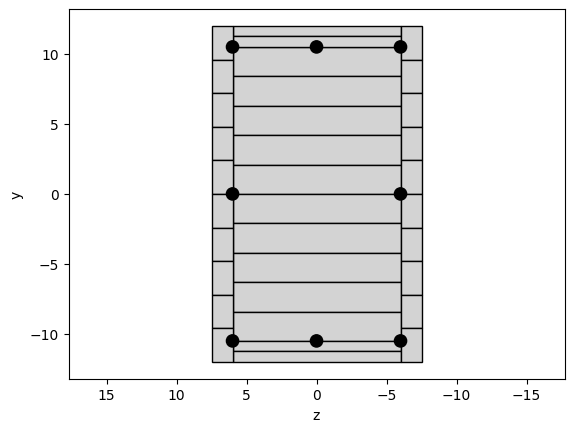

In [28]:
getSection()
# Call the section analysis procedure
MomentCurvature(1, P, Ky*mu, numIncr)

In [24]:
u = ops.nodeDisp(2,3)
if abs(u-0.00190476190476190541)<1e-12:
    print("Passed!")
else:
    print("Failed!")

Passed!


In [18]:
data = np.loadtxt("section1.txt", delimiter=" ")
data

array([[ 0.00000e+00, -1.09630e-21],
       [ 1.24530e+01,  1.90476e-05],
       [ 1.80951e+01,  3.80952e-05],
       [ 2.25069e+01,  5.71429e-05],
       [ 2.65824e+01,  7.61905e-05],
       [ 3.05258e+01,  9.52381e-05],
       [ 3.44132e+01,  1.14286e-04],
       [ 3.82088e+01,  1.33333e-04],
       [ 4.05879e+01,  1.52381e-04],
       [ 4.13633e+01,  1.71429e-04],
       [ 4.21259e+01,  1.90476e-04],
       [ 4.28753e+01,  2.09524e-04],
       [ 4.36108e+01,  2.28571e-04],
       [ 4.43319e+01,  2.47619e-04],
       [ 4.50362e+01,  2.66667e-04],
       [ 4.56644e+01,  2.85714e-04],
       [ 4.62814e+01,  3.04762e-04],
       [ 4.68868e+01,  3.23810e-04],
       [ 4.74696e+01,  3.42857e-04],
       [ 4.77171e+01,  3.61905e-04],
       [ 4.78353e+01,  3.80952e-04],
       [ 4.79299e+01,  4.00000e-04],
       [ 4.80229e+01,  4.19048e-04],
       [ 4.81143e+01,  4.38095e-04],
       [ 4.81923e+01,  4.57143e-04],
       [ 4.82600e+01,  4.76190e-04],
       [ 4.83276e+01,  4.95238e-04],
 

Text(0, 0.5, 'Moment')

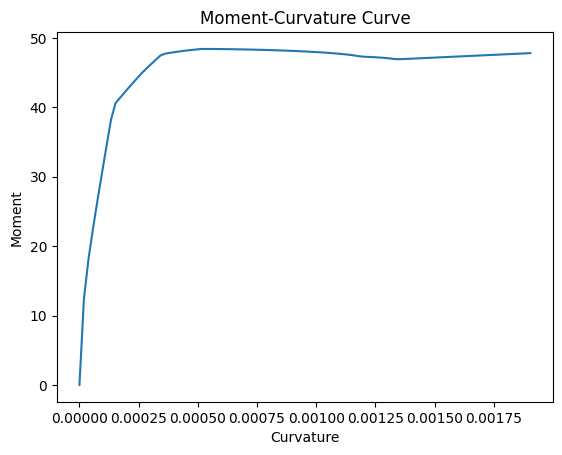

In [19]:
plt.plot(data[:, 1], data[:, 0])
plt.title("Moment-Curvature Curve")
plt.xlabel("Curvature")
plt.ylabel("Moment")